In [68]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

In [69]:
sentence = ["I","Love","Deep","Learning"]
print(sentence)

['I', 'Love', 'Deep', 'Learning']


In [70]:
word_embeddings={
    "I":1.0,
    "Love":2.0,
    "Deep":3.0,
    "Learning":4.0
}
print(word_embeddings)


{'I': 1.0, 'Love': 2.0, 'Deep': 3.0, 'Learning': 4.0}


In [71]:
X=np.array([
    [[word_embeddings["I"]],[word_embeddings["Love"]],[word_embeddings["Deep"]]],
    [[word_embeddings["I"]],[word_embeddings["Love"]],[word_embeddings["Learning"]]]
])

In [72]:
print(X)

[[[1.]
  [2.]
  [3.]]

 [[1.]
  [2.]
  [4.]]]


In [73]:
y=np.array([[word_embeddings["Learning"]], [word_embeddings["Learning"]]])
print(y)
print("Input shape,",X.shape)
print("output shape",y.shape)

[[4.]
 [4.]]
Input shape, (2, 3, 1)
output shape (2, 1)


In [74]:
model = Sequential()
model.add(SimpleRNN(
    units=8,
    activation='tanh',
    input_shape=(3,1)
))
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
model.compile(
    optimizer = 'adam',
    loss = 'mse'
)

In [76]:
model.fit(X,y,epochs=300,verbose=1)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 14.1827
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 14.0313
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 13.8810
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 13.7319
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 13.5840
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 13.4373
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 13.2918
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 13.1475
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 13.0045
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12.8628
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.7223
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.5830
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 12.4450
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 12.3082
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 12.1726
Epoch

In [77]:
#prediction
test_sequence = np.array([
    [[word_embeddings["I"]]],
    [[word_embeddings["Love"]]]
])

# Reshape for prediction to add a batch dimension: (1, timesteps, features)
prediction = model.predict(test_sequence.reshape(1, test_sequence.shape[0], test_sequence.shape[1]))
print("prediction",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
prediction 2.9482837


In [78]:
predicted_number = prediction[0][0]
closest_word = min(word_embeddings, key=lambda word: abs(word_embeddings[word] - predicted_number))
print("Predicted Word:", closest_word)

Predicted Word: Deep


In [79]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


In [80]:
import os
import pandas as pd
files = os.listdir(path)
print("Files:", files)


csv_path = os.path.join(path, files[0])

df = pd.read_csv(csv_path)


print(df.head())


Files: ['Combined Data.csv']
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [81]:
df.head(10)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,7,Have you ever felt nervous but didn't know why?,Anxiety
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,9,"I'm really worried, I want to cry.",Anxiety


In [82]:
df.isnull().sum()

,0
Unnamed: 0,0
statement,362
status,0


In [83]:
df.shape

(53043, 3)

In [84]:
df.dropna(subset=['statement'],inplace = True)

Dataset Shape:
(52681, 3)

Columns:
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

First 5 Rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

Number of Sentiment Classes:
7

Sentiment Classes:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']

Text Distribution:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


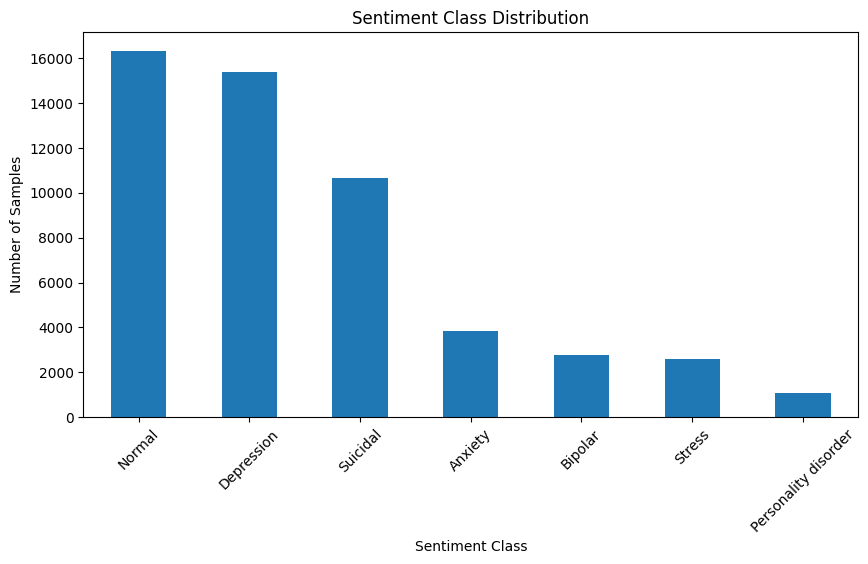


Class Imbalance Percentage:
status
Normal                  31.022570
Depression              29.240144
Suicidal                20.219814
Anxiety                  7.291054
Bipolar                  5.271350
Stress                   4.910689
Personality disorder     2.044380
Name: proportion, dtype: float64

Average Sentence Length:
113.16 words

Minimum Sentence Length:
1

Maximum Sentence Length:
6300


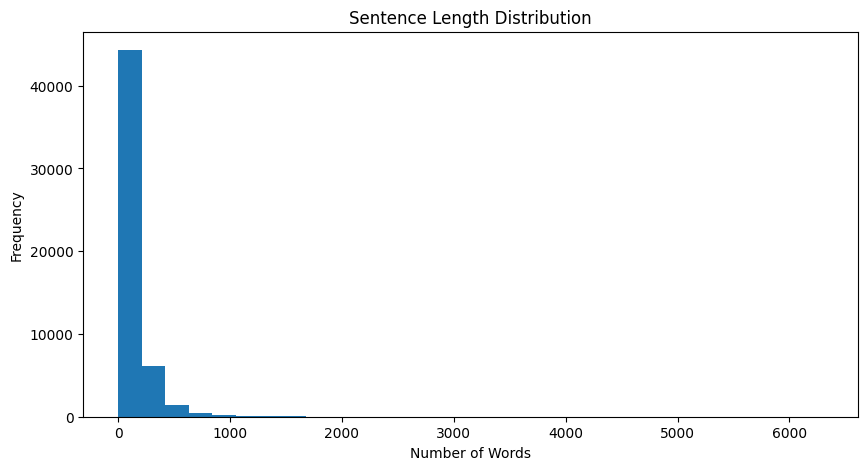

In [85]:

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt


print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================
# 1. NUMBER OF SENTIMENT CLASSES
# ============================================

num_classes = df['status'].nunique()

print("\nNumber of Sentiment Classes:")
print(num_classes)

print("\nSentiment Classes:")
print(df['status'].unique())

# ============================================
# 2. TEXT DISTRIBUTION
# ============================================

class_distribution = df['status'].value_counts()

print("\nText Distribution:")
print(class_distribution)

# Plot distribution
plt.figure(figsize=(10,5))
class_distribution.plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()

# ============================================
# 3. CLASS IMBALANCE
# ============================================

print("\nClass Imbalance Percentage:")

imbalance_percentage = (
    df['status'].value_counts(normalize=True) * 100
)

print(imbalance_percentage)

# ============================================
# 4. AVERAGE SENTENCE LENGTH
# ============================================

# Word count per sentence
df['sentence_length'] = df['statement'].apply(
    lambda x: len(str(x).split())
)

average_length = df['sentence_length'].mean()

print("\nAverage Sentence Length:")
print(round(average_length, 2), "words")

# ============================================
# EXTRA ANALYSIS
# ============================================

print("\nMinimum Sentence Length:")
print(df['sentence_length'].min())

print("\nMaximum Sentence Length:")
print(df['sentence_length'].max())

# ============================================
# HISTOGRAM OF SENTENCE LENGTH
# ============================================

plt.figure(figsize=(10,5))

plt.hist(df['sentence_length'], bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [86]:
#drop column Unnamed
df.drop('Unnamed: 0',axis=1,inplace=True)

In [87]:
df.head()

,statement,status,sentence_length
0,oh my gosh,Anxiety,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14
3,I've shifted my focus to something else but I'...,Anxiety,11
4,"I'm restless and restless, it's been a month n...",Anxiety,14


In [88]:

import pandas as pd
import numpy as np
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================
# CHECK DATA
# ============================================

print(df.head())

# ============================================
# 1. LOWERCASE CONVERSION
# ============================================

df['clean_text'] = df['statement'].str.lower()

print("\nAfter Lowercase Conversion:")
print(df['clean_text'].head())


def remove_punctuation(text):

    # remove punctuation using regex
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    return text

df['clean_text'] = df['clean_text'].apply(remove_punctuation)

print("\nAfter Punctuation Removal:")
print(df['clean_text'].head())

# ============================================
# 3. STOPWORD REMOVAL
# ============================================

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

print("\nAfter Stopword Removal:")
print(df['clean_text'].head())

# ============================================
# 4. TOKENIZATION
# ============================================

df['tokens'] = df['clean_text'].apply(word_tokenize)

print("\nTokenized Text:")
print(df['tokens'].head())

# ============================================
# 5. VOCABULARY GENERATION
# ============================================

# Maximum vocabulary size
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE)

# Learn vocabulary from text
tokenizer.fit_on_texts(df['clean_text'])

# Vocabulary dictionary
word_index = tokenizer.word_index

print("\nVocabulary Size:")
print(len(word_index))

# ============================================
# TEXT TO SEQUENCES
# ============================================

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

print("\nSample Sequence:")
print(sequences[0])

# ============================================
# 6. PADDING
# ============================================

MAX_LENGTH = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("\nShape After Padding:")
print(padded_sequences.shape)

print("\nFirst Padded Sequence:")
print(padded_sequences[0])

# ============================================
# FINAL OUTPUT
# ============================================

X = padded_sequences
y = df['status']

print("\nFinal Feature Shape:", X.shape)
print("Final Label Shape:", y.shape)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                           statement   status  sentence_length
0                                         oh my gosh  Anxiety                3
1  trouble sleeping, confused mind, restless hear...  Anxiety               10
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety               14
3  I've shifted my focus to something else but I'...  Anxiety               11
4  I'm restless and restless, it's been a month n...  Anxiety               14

After Lowercase Conversion:
0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    all wrong, back off dear, forward doubt. stay ...
3    i've shifted my focus to something else but i'...
4    i'm restless and restless, it's been a month n...
Name: clean_text, dtype: object

After Punctuation Removal:
0                                           oh my gosh
1    trouble sleeping confused mind restless heart ...
2    all wrong back off dear forward doubt stay in .

In [89]:
df.head()

,statement,status,sentence_length,clean_text,tokens
0,oh my gosh,Anxiety,3,oh gosh,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless heart ...,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,11,ive shifted focus something else im still worried,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,14,im restless restless month boy mean,"[im, restless, restless, month, boy, mean]"


In [90]:
# ============================================
# TASK 3 — SEQUENCE PREPARATION
# ============================================

# ============================================
# IMPORT LIBRARIES
# ============================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================
# SAMPLE CLEAN TEXT
# ============================================

print(df['clean_text'].head())

# ============================================
# 1. TOKENIZER
# ============================================

VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Learn words from dataset
tokenizer.fit_on_texts(df['clean_text'])

# ============================================
# 2. WORD INDEXING
# ============================================

word_index = tokenizer.word_index

print("\nWord Index:")
print(list(word_index.items())[:10])

# ============================================
# 3. TEXT TO NUMERICAL SEQUENCES
# ============================================

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

print("\nOriginal Sentence:")
print(df['clean_text'][0])

print("\nConverted Sequence:")
print(sequences[0])

# ============================================
# 4. PADDED SEQUENCES
# ============================================

MAX_LENGTH = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("\nPadded Sequence:")
print(padded_sequences[0])

print("\nShape of Padded Data:")
print(padded_sequences.shape)

# ============================================
# FINAL FEATURES
# ============================================

X = padded_sequences
y = df['status']

print("\nFinal X Shape:", X.shape)
print("Final y Shape:", y.shape)

0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
3    ive shifted focus something else im still worried
4                  im restless restless month boy mean
Name: clean_text, dtype: object

Word Index:
[('<OOV>', 1), ('like', 2), ('feel', 3), ('want', 4), ('know', 5), ('life', 6), ('get', 7), ('even', 8), ('time', 9), ('would', 10)]

Original Sentence:
oh gosh

Converted Sequence:
[495, 4666]

Padded Sequence:
[ 495 4666    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

Shape of Padded Data:
(52681, 50)

Final X Shape: (52681, 50)
Final y Shape: (52681,)


In [91]:
df.head()

,statement,status,sentence_length,clean_text,tokens
0,oh my gosh,Anxiety,3,oh gosh,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless heart ...,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,11,ive shifted focus something else im still worried,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,14,im restless restless month boy mean,"[im, restless, restless, month, boy, mean]"


In [92]:
X

array([[ 495, 4666,    0, ...,    0,    0,    0],
       [ 809,  520,  835, ...,    0,    0,    0],
       [ 170,   27, 2114, ...,    0,    0,    0],
       ...,
       [  42,  107,   44, ...,    0,    0,    0],
       [1142, 1345,  875, ...,    0,    0,    0],
       [  12,   52,  975, ...,    0,    0,    0]], dtype=int32)

In [93]:
y

,status
0,Anxiety
1,Anxiety
2,Anxiety
3,Anxiety
4,Anxiety
...,...
53038,Anxiety
53039,Anxiety
53040,Anxiety
53041,Anxiety


In [94]:
# ============================================
# TASK 4 — SIMPLE RNN MODEL
# ============================================

# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

# ============================================
# LABEL ENCODING
# ============================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels:")
print(y_encoded[:10])

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================
# MODEL PARAMETERS
# ============================================

VOCAB_SIZE = 10000
MAX_LENGTH = 50
EMBEDDING_DIM = 128
RNN_UNITS = 64

NUM_CLASSES = len(np.unique(y_encoded))

print("\nNumber of Classes:", NUM_CLASSES)

# ============================================
# BUILD SIMPLE RNN MODEL
# ============================================

model = Sequential()

# ============================================
# 1. EMBEDDING LAYER
# ============================================

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    )
)

model.add(
    SimpleRNN(
        RNN_UNITS,
        activation='tanh'
    )
)


model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# MODEL SUMMARY
# ============================================

model.summary()

Encoded Labels:
[0 0 0 0 0 0 0 0 0 0]

Training Shape: (42144, 50)
Testing Shape: (10537, 50)

Number of Classes: 7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
    verbose=1
)
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/5
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.5649 - loss: 1.1795 - val_accuracy: 0.4601 - val_loss: 1.5424
Epoch 2/5
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.6142 - loss: 1.0630 - val_accuracy: 0.4409 - val_loss: 1.6444
Epoch 3/5
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - accuracy: 0.6469 - loss: 1.0027 - val_accuracy: 0.4674 - val_loss: 1.7553
Epoch 4/5
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6772 - loss: 0.9408 - val_accuracy: 0.4804 - val_loss: 1.7396
Epoch 5/5
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7201 - loss: 0.8407 - val_accuracy: 0.4973 - val_loss: 1.6873
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4973 - loss: 1.6873

Test Loss: 1.687334656715393
Test Accuracy: 0.49729523062705994


330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Accuracy:
0.4382

Precision:
0.3993

Recall:
0.4382

F1 Score:
0.3641

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.26      0.14      0.18       755
             Bipolar       0.34      0.11      0.17       527
          Depression       0.44      0.30      0.36      3016
              Normal       0.47      0.98      0.64      3308
Personality disorder       0.54      0.03      0.06       237
              Stress       0.33      0.03      0.05       536
            Suicidal       0.30      0.13      0.18      2158

            accuracy                           0.44     10537
           macro avg       0.38      0.25      0.23     10537
        weighted avg       0.40      0.44      0.36     10537


Confusion Matrix:
[[ 102   25  192  351    0    9   76]
 [  70   58  161  180    1    2   55]
 [ 102   48  898 1512    2   13  441]
 [   6    1   29 3249    0    2   21]
 [  24 

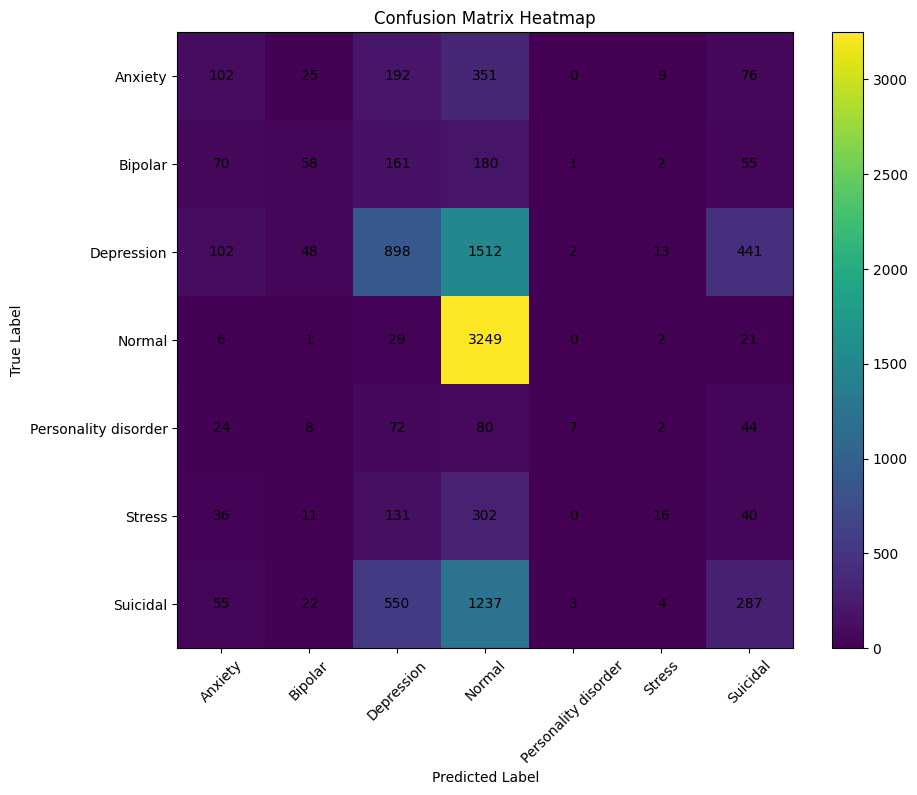

In [96]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:")
print(round(accuracy, 4))
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("\nPrecision:")
print(round(precision, 4))


recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("\nRecall:")
print(round(recall, 4))


f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("\nF1 Score:")
print(round(f1, 4))


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(10,8))

plt.imshow(cm)

classes = label_encoder.classes_
plt.xticks(
    ticks=np.arange(len(classes)),
    labels=classes,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(classes)),
    labels=classes
)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.title("Confusion Matrix Heatmap")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.show()

In [98]:
# ============================================
# TASK 8 — REAL-TIME PREDICTION
# ============================================

# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np

# ============================================
# PREDICTION FUNCTION
# ============================================

def predict_emotion(text):

    # ----------------------------------------
    # 1. LOWERCASE
    # ----------------------------------------

    text = text.lower()

    # ----------------------------------------
    # 2. REMOVE PUNCTUATION
    # ----------------------------------------

    text = remove_punctuation(text)

    # ----------------------------------------
    # 3. REMOVE STOPWORDS
    # ----------------------------------------

    text = remove_stopwords(text)

    print("\nCleaned Text:", text)

    # ----------------------------------------
    # 4. TEXT TO SEQUENCE
    # ----------------------------------------

    sequence = tokenizer.texts_to_sequences([text])

    print("Sequence:", sequence)

    # ----------------------------------------
    # 5. PADDING
    # ----------------------------------------

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding='post'
    )

    # ----------------------------------------
    # 6. MODEL PREDICTION
    # ----------------------------------------

    prediction = model.predict(padded)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    emotion = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    # ----------------------------------------
    # 7. OUTPUT
    # ----------------------------------------

    print("\nPredicted Emotion:", emotion)

    print(
        "Confidence Score:",
        round(confidence * 100, 2),
        "%"
    )

    return emotion

# ============================================
# TEST 1 — CUSTOM USER SENTENCE
# ============================================

text1 = "I feel very stressed and anxious lately"

predict_emotion(text1)

# ============================================
# TEST 2 — EMOTIONAL TEXT EXAMPLE
# ============================================

text2 = "I am extremely happy and excited today"

predict_emotion(text2)

# ============================================
# TEST 3 — UNSEEN SENTENCE
# ============================================

text3 = "Nobody understands my feelings anymore"

predict_emotion(text3)


Cleaned Text: feel stressed anxious lately
Sequence: [[3, 488, 251, 384]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step

Predicted Emotion: Depression
Confidence Score: 42.39 %

Cleaned Text: extremely happy excited today
Sequence: [[337, 95, 951, 130]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Predicted Emotion: Depression
Confidence Score: 54.87 %

Cleaned Text: nobody understands feelings anymore
Sequence: [[297, 1505, 280, 26]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Predicted Emotion: Normal
Confidence Score: 44.1 %


'Normal'

In [99]:
# ============================================
# SAVE MODEL AS .H5 FILE
# ============================================

# Save trained model
model.save("mental_health_rnn_model.h5")

print("Model saved successfully!")

# ============================================
# DOWNLOAD MODEL (GOOGLE COLAB)
# ============================================

from google.colab import files

files.download("mental_health_rnn_model.h5")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>